# Descarga de los datos


---



In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.utils import image_dataset_from_directory

In [ ]:
#Imports

import joblib

from tensorflow import keras
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
#Ruta del dataset
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print("Ruta de archivos:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Ruta de archivos: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
#Carpetas en la ruta que se descarga
!ls {path}/HAM10000_images_part_2 | head -n 5

ISIC_0029306.jpg
ISIC_0029307.jpg
ISIC_0029308.jpg
ISIC_0029309.jpg
ISIC_0029310.jpg


In [4]:
#Copia del dataset a Content
!cp -r {path}/* ./
#!rm -rf ./*

In [5]:
#Carpetas dentro de content
!ls ./HAM10000_images_part_1/ | head -n 5
#!ls ./HAM10000_images_part_2/ | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


In [6]:
#Ruta dentro de la carpeta content
#path_content = "skin-cancer-mnist-ham10000"
path_content = ""

#Ruta de los archivo csv
data_csv = os.path.join(path_content, "HAM10000_metadata.csv")
print("Ruta de archivos data csv:", data_csv)

hmnist_28_csv = os.path.join(path_content, "hmnist_28_28_RGB.csv")
print("Ruta de archivos hmnist_28_csv:", hmnist_28_csv)

#Ruta de las imagenes
folder_img_1 = "HAM10000_images_part_1"
images_dir_1 = os.path.join(path_content, folder_img_1)
print("Ruta de imagenes parte 1:", images_dir_1)

folder_img_2 = "HAM10000_images_part_2"
images_dir_2 = os.path.join(path_content, folder_img_2)
print("Ruta de imagenes parte 2:", images_dir_2)

#Directorio para unificar las imagenes.
folder_img_all = "HAM10000_images_all"
images_dir_all = os.path.join(path_content, folder_img_all)
print("Ruta de imagenes completo", images_dir_all)

Ruta de archivos data csv: HAM10000_metadata.csv
Ruta de archivos hmnist_28_csv: hmnist_28_28_RGB.csv
Ruta de imagenes parte 1: HAM10000_images_part_1
Ruta de imagenes parte 2: HAM10000_images_part_2
Ruta de imagenes completo HAM10000_images_all


In [7]:
#Exploración de los dataset (CSV)
raw_df = pd.read_csv(data_csv, on_bad_lines="skip")
raw_df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
#Explicación del campo dx_type
raw_df['dx_type'].value_counts()

#histo (5340) — confirmado por histopatología (biopsia analizada en laboratorio). Es el método más fiable.
#follow_up (3704) — confirmado por seguimiento clínico a lo largo del tiempo, observando la evolución de la lesión.
#consensus (902) — diagnóstico por consenso de expertos (varios dermatólogos coinciden en el diagnóstico).
#confocal (69) — diagnosticado mediante microscopía confocal in vivo, una técnica de imagen no invasiva.


,count
dx_type,
histo,5340
follow_up,3704
consensus,902
confocal,69


In [9]:
#Se crea el directorio, donde se consolidan todas las imagenes.
!mkdir ./{folder_img_all}/

In [10]:
#Se mueven las imagenes a un solo directorio
!mv ./{folder_img_1}/* ./{folder_img_all}/
!mv ./{folder_img_2}/* ./{folder_img_all}/

In [11]:
#Se validan los directorios
!ls ./{folder_img_1}/ | head -n 5
!ls ./{folder_img_2}/ | head -n 5

In [12]:
!ls ./{folder_img_all} | head -n 5

ISIC_0024306.jpg
ISIC_0024307.jpg
ISIC_0024308.jpg
ISIC_0024309.jpg
ISIC_0024310.jpg


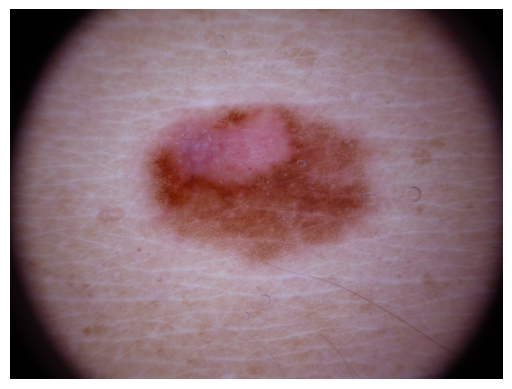

(450, 600, 3)
lesion_id        HAM_0005711
image_id        ISIC_0033779
dx                       mel
dx_type                histo
age                     35.0
sex                     male
localization            back
Name: 1642, dtype: object


In [13]:
#Se muestra una imagen de ejemplo
idx = 1642
row = raw_df.iloc[idx]
image_path = f"./{folder_img_all}/{row["image_id"]}.jpg"
image = cv2.imread(image_path)[:, :, ::-1]

plt.imshow(image)
plt.axis("off")
plt.show()

print(image.shape)
print(row)


#Preparación del data set


---



In [14]:
#Preparación del data set
#df = raw_df.drop_duplicates(subset=["lesion_id"]).copy()
df = raw_df.copy()
df['id'] = df['lesion_id'].str.replace('HAM_', '', regex=False)
df["id"] = pd.to_numeric(df["id"], errors="coerce")
df = df.dropna(subset=["id", "dx"]).copy()

df["dx"] = df["dx"].astype(str).str.strip()
df["dx_type"] = df["dx_type"].astype(str).str.strip()
df["sex"] = df["sex"].astype(str).str.strip()
df["localization"] = df["localization"].astype(str).str.strip()
df["image_path"] = df["image_id"].astype(str).map(lambda x: os.path.join(images_dir_all, f"{x}.jpg"))
df = df[df["image_path"].map(os.path.exists)].reset_index(drop=True)

In [15]:
#Definición de variables categoricas y numericas
df = raw_df.copy()
class_names = sorted(df["dx"].unique().tolist())
class_to_index = {name: i for i, name in enumerate(class_names)}
df["label"] = df["dx"].map(class_to_index).astype(np.int32)

In [16]:
#Labels para la creación del data set desde el directorio, contiene la
# clasificacion dx de las imagenes, debe estar ordenado por image_id = al directorio
df_sorted = df.sort_values("image_id")
labels = df_sorted["label"].tolist()
labels[:5]

[5, 5, 5, 5, 4]

#Fine tunning - Modelo Imagenes VGG16, VGG19, ResNet50


---



In [17]:
#Imports necesarios
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.layers import Dropout, Flatten, Dense, Lambda, Input, GlobalAveragePooling2D, Resizing
from tensorflow.keras.optimizers import Adam

In [18]:
#Preparacion del dataset
#Ordenar para que coincida con el orden de listdir
train_ds = image_dataset_from_directory(
    "./HAM10000_images_all",
    labels=labels,
    label_mode="int",
    image_size=(224, 224),
    batch_size=128,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=10
)

validation_ds = image_dataset_from_directory(
    "./HAM10000_images_all",
    labels=labels,
    label_mode="int",
    image_size=(224, 224),
    batch_size=128,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=10
)

Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.


### Modelo VGG16

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input

In [23]:
#Preprocesamiento de las imagenes de acuerdo a la funcion del modelo.
def preprocess_images(images, labels):
  images = tf.cast(images, tf.float32)
  images = preprocess_input(images)
  return images, labels

train_ds = train_ds.map(preprocess_images)
validation_ds = validation_ds.map(preprocess_images)

In [24]:
#Extración de caracteristicas
feature_extractor = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
feature_extractor.trainable = False
feature_extractor.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [25]:
#Capa de input y preprocesamiento
input_tensor = Input(shape=(224, 224, 3))
preprocessed_input = Lambda(preprocess_input)(input_tensor)

#Capa de extraccción de caracteristicas de un modelo
image_features = feature_extractor(preprocessed_input, training=False)

#Capa de conversión a Flatten
flattened_features = GlobalAveragePooling2D()(image_features)
dropped_flattened = Dropout(0.25)(flattened_features)
intermediate_layer = Dense(256, activation="relu")(dropped_flattened)

#Clasificacion
model_output = Dense(len(class_names), activation="softmax")(intermediate_layer)

#Creación de modelo
model = Model(inputs=input_tensor, outputs=model_output)

#Muestra el modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,815 (56.64 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [26]:
#Optimizador y Compilación del modelo
optimizer = Adam(1e-5)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [27]:
#Entrenamiento
history = model.fit(train_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.0842 - loss: 5.1941 - val_accuracy: 0.1717 - val_loss: 3.0877
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.2607 - loss: 3.1663 - val_accuracy: 0.4793 - val_loss: 2.0267
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.4448 - loss: 2.4501 - val_accuracy: 0.5926 - val_loss: 1.9130
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.5107 - loss: 2.2518 - val_accuracy: 0.6111 - val_loss: 1.8891
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5364 - loss: 2.1146 - val_accuracy: 0.6146 - val_loss: 1.8647
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.5477 - loss: 2.0337 - val_accuracy: 0.6086 - val_loss: 1.8464
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5625 - loss: 1.9362 - val_accuracy: 0.5971 - val_loss: 1.8316
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5638 - loss: 1.9002 - val_accuracy: 0.5966 - val_loss

### Modelo VGG19

In [28]:
from tensorflow.keras.applications.vgg19 import preprocess_input

In [29]:
#Preprocesamiento de las imagenes de acuerdo a la funcion del modelo.
def preprocess_images(images, labels):
  images = tf.cast(images, tf.float32)
  images = preprocess_input(images)
  return images, labels

train_ds = train_ds.map(preprocess_images)
validation_ds = validation_ds.map(preprocess_images)

In [30]:
#Extración de caracteristicas
feature_extractor = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
feature_extractor.trainable = False
feature_extractor.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [31]:
#Capa de input y preprocesamiento
input_tensor = Input(shape=(224, 224, 3))
preprocessed_input = Lambda(preprocess_input)(input_tensor)

#Capa de extraccción de caracteristicas de un modelo
image_features = feature_extractor(preprocessed_input, training=False)

#Capa de conversión a Flatten
flattened_features = GlobalAveragePooling2D()(image_features)
dropped_flattened = Dropout(0.25)(flattened_features)
intermediate_layer = Dense(256, activation="relu")(dropped_flattened)

#Clasificacion
model_output = Dense(len(class_names), activation="softmax")(intermediate_layer)

#Creación de modelo
model = Model(inputs=input_tensor, outputs=model_output)

#Muestra el modelo
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,511 (76.89 MB)

 Trainable params: 133,127 (520.03 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [32]:
#Optimizador y Compilación del modelo
optimizer = Adam(1e-5)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [33]:
#Entrenamiento
history = model.fit(train_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.2571 - loss: 3.9649 - val_accuracy: 0.3050 - val_loss: 3.0998
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.3990 - loss: 3.1304 - val_accuracy: 0.4244 - val_loss: 2.6849
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.4685 - loss: 2.7951 - val_accuracy: 0.4598 - val_loss: 2.5293
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.4953 - loss: 2.5419 - val_accuracy: 0.4838 - val_loss: 2.4305
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.5231 - loss: 2.3991 - val_accuracy: 0.5042 - val_loss: 2.3622
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5454 - loss: 2.2866 - val_accuracy: 0.5112 - val_loss: 2.3194
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.5524 - loss: 2.1790 - val_accuracy: 0.5142 - val_loss: 2.2993
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.5690 - loss: 2.0619 - val_accuracy: 0.5197 - val_los

### Modelo ResNet50

In [22]:
from tensorflow.keras.applications.resnet50 import preprocess_input

In [23]:
#Preprocesamiento de las imagenes de acuerdo a la funcion del modelo.
def preprocess_images(images, labels):
  images = tf.cast(images, tf.float32)
  images = preprocess_input(images)
  return images, labels

train_ds = train_ds.map(preprocess_images)
validation_ds = validation_ds.map(preprocess_images)

In [24]:
#Extración de caracteristicas
feature_extractor = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
feature_extractor.trainable = False
feature_extractor.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
#Capa de input y preprocesamiento
input_tensor = Input(shape=(224, 224, 3))
preprocessed_input = Lambda(preprocess_input)(input_tensor)

#Capa de extraccción de caracteristicas de un modelo
image_features = feature_extractor(preprocessed_input, training=False)

#Capa de conversión a Flatten
flattened_features = GlobalAveragePooling2D()(image_features)
dropped_flattened = Dropout(0.25)(flattened_features)
intermediate_layer = Dense(256, activation="relu")(dropped_flattened)

#Clasificacion
model_output = Dense(len(class_names), activation="softmax")(intermediate_layer)

#Creación de modelo
model = Model(inputs=input_tensor, outputs=model_output)

#Muestra el modelo
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,055 (91.99 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [38]:
#Optimizador y Compilación del modelo
optimizer = Adam(1e-5)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [39]:
#Entrenamiento
history = model.fit(train_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.4527 - loss: 1.7425 - val_accuracy: 0.6745 - val_loss: 1.2472
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.6108 - loss: 1.3815 - val_accuracy: 0.6745 - val_loss: 1.1854
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6272 - loss: 1.3121 - val_accuracy: 0.6745 - val_loss: 1.1757
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.6368 - loss: 1.2363 - val_accuracy: 0.6745 - val_loss: 1.1782
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.6437 - loss: 1.2076 - val_accuracy: 0.6745 - val_loss: 1.1854
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6516 - loss: 1.1527 - val_accuracy: 0.6730 - val_loss: 1.1954
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6545 - loss: 1.1193 - val_accuracy: 0.6710 - val_loss: 1.2088
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.6596 - loss: 1.0950 - val_accuracy: 0.6700 - val_lo

### Modificación sobre la capa de clasificación
Se agrega una capa densa y dropout

In [25]:
#Capa de input y preprocesamiento
input_tensor = Input(shape=(224, 224, 3))
preprocessed_input = Lambda(preprocess_input)(input_tensor)

#Capa de extraccción de caracteristicas de un modelo
image_features = feature_extractor(preprocessed_input, training=False)

#Capa de conversión a Flatten
flattened_features = GlobalAveragePooling2D()(image_features)
dropped_flattened = Dropout(0.25)(flattened_features)
intermediate_layer = Dense(256, activation="relu")(dropped_flattened)
intermediate_layer = Dropout(0.25)(intermediate_layer)

intermediate_layer = Dense(256, activation="relu")(intermediate_layer)
intermediate_layer = Dropout(0.25)(intermediate_layer)

#Clasificacion
model_output = Dense(len(class_names), activation="softmax")(intermediate_layer)

#Creación de modelo
model = Model(inputs=input_tensor, outputs=model_output)

In [26]:
#Optimizador y Compilación del modelo
optimizer = Adam(1e-5)
model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [27]:
#Entrenamiento
history = model.fit(train_ds, validation_data=validation_ds, epochs=10)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.2118 - loss: 2.2629 - val_accuracy: 0.6620 - val_loss: 1.3976
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.5283 - loss: 1.4873 - val_accuracy: 0.6745 - val_loss: 1.2394
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5941 - loss: 1.3619 - val_accuracy: 0.6745 - val_loss: 1.2264
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.6248 - loss: 1.2685 - val_accuracy: 0.6750 - val_loss: 1.2272
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6337 - loss: 1.2192 - val_accuracy: 0.6745 - val_loss: 1.2358
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.6352 - loss: 1.1937 - val_accuracy: 0.6720 - val_loss: 1.2471
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6408 - loss: 1.1753 - val_accuracy: 0.6665 - val_loss: 1.2616
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6519 - loss: 1.1172 - val_accuracy: 0.6625 - val_loss